In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
true = pd.read_csv(r"F:\OneDrive - Graphic Era University\Desktop\mini-project\fake-news-detection\data\True.csv")
fake = pd.read_csv(r"F:\OneDrive - Graphic Era University\Desktop\mini-project\fake-news-detection\data\Fake.csv")


In [5]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], axis= 0)
df = df.sample(frac=1).reset_index(drop=True) 

In [8]:
df.head()

,title,text,subject,date,label
0,MEDIA IGNORES! HOUSE DEM IT SUSPECTS Wanted Un...,The media has ignored the case of Muslim Broth...,Government News,"Jul 5, 2017",0
1,"In Nairobi slum, rock-throwers, police keep vo...",NAIROBI (Reuters) - It had all the trappings o...,worldnews,"October 26, 2017",1
2,Trump 'plain wrong' to say Muslims not helping...,LONDON (Reuters) - Britain’s interior minister...,politicsNews,"March 23, 2016",1
3,Anti-nuclear campaign ICAN says Nobel Peace Pr...,OSLO (Reuters) - The International Campaign fo...,worldnews,"October 6, 2017",1
4,HEY HILLARY…WHO IS REALLY BEHIND Attempt By Pa...,Is it possible the curtain has been pulled bac...,left-news,"Jul 24, 2016",0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 1.7 MB


In [10]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')

In [11]:
df.shape

(44898, 5)

In [12]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [13]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

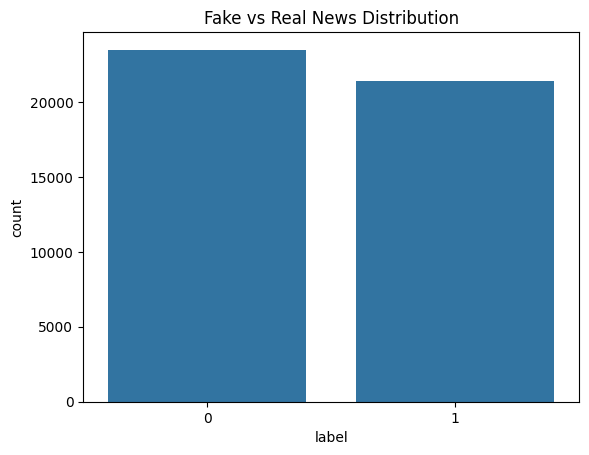

In [14]:
sns.countplot(x = "label", data = df)
plt.title("Fake vs Real News Distribution")
plt.show()

In [15]:
df['text_length'] = df['text'].apply(len)

df['text_length'].describe

<bound method NDFrame.describe of 0        6494
1        2997
2         782
3        3207
4        4441
         ... 
44893    2704
44894    2119
44895     414
44896    2381
44897    2005
Name: text_length, Length: 44898, dtype: int64>

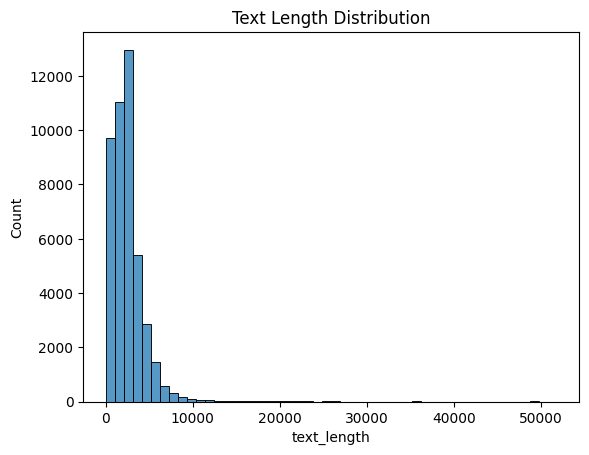

In [16]:
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

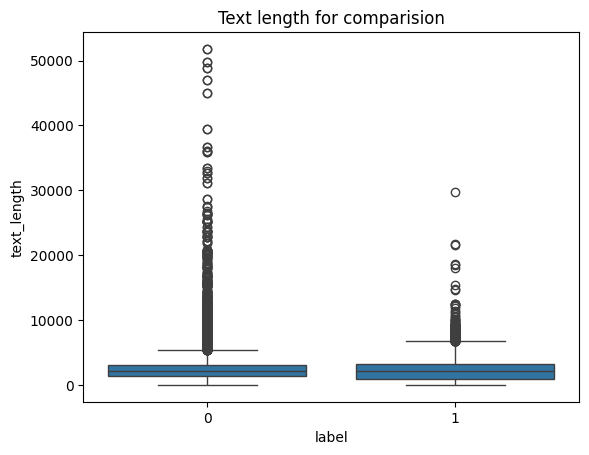

In [17]:
sns.boxplot(x = 'label', y= 'text_length', data = df)
plt.title("Text length for comparision")
plt.show()

In [18]:
df['subject'].value_counts()

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

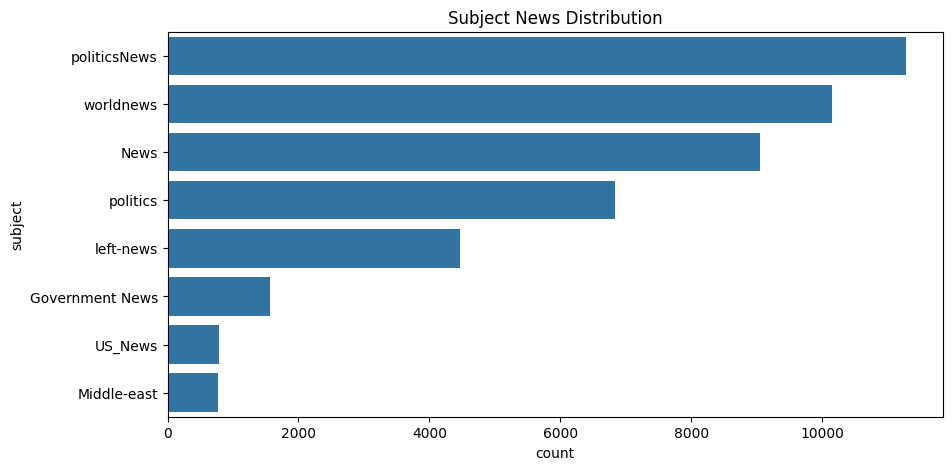

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(y = df['subject'], order=df['subject'].value_counts().index)
plt.title("Subject News Distribution")
plt.show()

In [20]:
pd.crosstab(df['subject'], df['label'])

label,0,1
subject,,
Government News,1570,0
Middle-east,778,0
News,9050,0
US_News,783,0
left-news,4459,0
politics,6841,0
politicsNews,0,11272
worldnews,0,10145


In [21]:
print("FAKE NEWS:\n", df[df['label']==0]['text'].iloc[0])
print("\nREAL NEWS:\n", df[df['label']==1]['text'].iloc[0])

FAKE NEWS:
 The media has ignored the case of Muslim Brotherhood connected brothers who hacked the DNC and now it s looking like they worked their magic to make millions disappear! They had access to the Congressional IT system! Can you believe that? Maria Bartiromo couldn t believe it when this first broke:A Pakistani family under criminal investigation by the U.S. Capitol Police (see our previous report below) for abusing their access to the House of Representatives information technology (IT) system may have engaged in myriad other questionable schemes besides allegedly placing  ghost employees  on the congressional payroll.Imran Awan, his wife Hina, and brothers Abid and Jamal collectively netted more than $4 million in salary as IT administrators for House Democrats between 2009 and 2017. Yet the absence of signs of wealth displayed among them raise questions such as was the money sent overseas or did something other than paychecks motivate their actions?Capitol Police revoked the

In [22]:
df.duplicated().sum()

np.int64(209)

In [23]:
df = df.drop_duplicates()

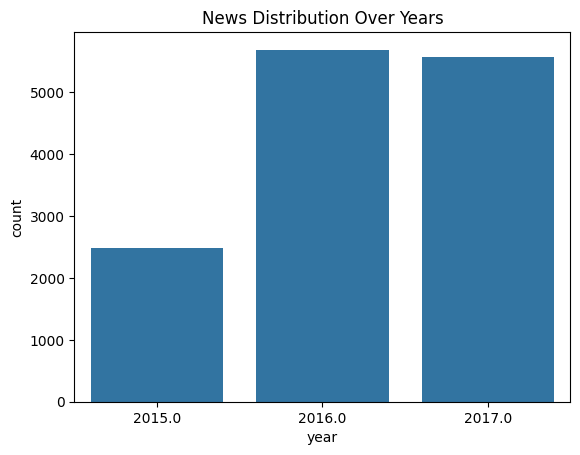

In [24]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year

sns.countplot(x='year', data=df)
plt.title("News Distribution Over Years")
plt.show()

In [25]:
df[['text_length', 'label']].corr()

,text_length,label
text_length,1.000000,-0.038944
label,-0.038944,1.000000


In [26]:
df.to_csv("cleaned_data.csv", index=False)